<a href="https://colab.research.google.com/github/tnwlvos/Purdue-AI-education-Muchine-Learning-/blob/main/PurdueAI_Final_project_datamake.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount("/content/drive")


Mounted at /content/drive


In [3]:
from datetime import datetime, timedelta
from pathlib import Path
import os
import pandas as pd
import soundfile as sf
import re
import numpy as np
import mmap
import wave
import matplotlib.pyplot as plt

In [8]:
PROJECT_DIR = Path(
    "/content/drive/MyDrive/Friction Stir Spot Welding (FSSW)"
)
RAW_DIR = PROJECT_DIR / "[1] raw sound data"
PROCESSED_DIR = PROJECT_DIR / "[2] processed sound data"
SEGMENT_DIR = PROCESSED_DIR / "[1] segment by experiment"
PLUNGE_DIR = PROCESSED_DIR / "[2] plunge"
DWELL_DIR = PROCESSED_DIR / "[3] dwell"

In [5]:


print(os.listdir("/content/drive/MyDrive"))

['Colab Notebooks', 'mnist', 'kaggle_cache', 'ColabModels', 'yolo_train.zip', '.ipynb_checkpoints', 'term_project.zip', '이상훈 백업자료.zip', 'test', 'motor_exam1', 'motor_example', 'Embedded-OS-Lecture', '임베디드응용sw', '베릴로그', '고멀쓰ppt.zip', 'Friction Stir Spot Welding (FSSW)']


In [6]:

paths = {
    "PROJECT": Path(PROJECT_DIR),
    "RAW": Path(RAW_DIR),
    "PROCESSED": Path(PROCESSED_DIR),
    "PLUNGE": Path(PLUNGE_DIR),
    "DWELL": Path(DWELL_DIR),
}

for name, path in paths.items():
    wav_count = len(list(path.glob("*.wav"))) if path.exists() else 0
    print(f"{name:10s} | 존재: {path.exists()} | WAV: {wav_count:3d}")
    print(f"  {path}")

PROJECT    | 존재: True | WAV:   0
  /content/drive/MyDrive/Friction Stir Spot Welding (FSSW)
RAW        | 존재: True | WAV:   4
  /content/drive/MyDrive/Friction Stir Spot Welding (FSSW)/[1] raw sound data
PROCESSED  | 존재: True | WAV:   0
  /content/drive/MyDrive/Friction Stir Spot Welding (FSSW)/[2] processed sound data
PLUNGE     | 존재: True | WAV:  27
  /content/drive/MyDrive/Friction Stir Spot Welding (FSSW)/[2] processed sound data/[2] plunge
DWELL      | 존재: False | WAV:   0
  /content/drive/MyDrive/Friction Stir Spot Welding (FSSW)/[2] processed sound data/[2] dwell


In [ ]:
def numbered_wavs(folder):
    return sorted(
        Path(folder).glob("*.wav"),
        key=lambda p: int(p.stem)
    )

plunge_files = numbered_wavs(PLUNGE_DIR)
dwell_files = numbered_wavs(DWELL_DIR)

print("Plunge:", len(plunge_files), [p.name for p in plunge_files])
print("Dwell: ", len(dwell_files), [p.name for p in dwell_files])

Plunge: 27 ['1.wav', '2.wav', '3.wav', '4.wav', '5.wav', '6.wav', '7.wav', '8.wav', '9.wav', '10.wav', '11.wav', '12.wav', '13.wav', '14.wav', '15.wav', '16.wav', '17.wav', '18.wav', '19.wav', '20.wav', '21.wav', '22.wav', '23.wav', '24.wav', '25.wav', '26.wav', '27.wav']
Dwell:  27 ['1.wav', '2.wav', '3.wav', '4.wav', '5.wav', '6.wav', '7.wav', '8.wav', '9.wav', '10.wav', '11.wav', '12.wav', '13.wav', '14.wav', '15.wav', '16.wav', '17.wav', '18.wav', '19.wav', '20.wav', '21.wav', '22.wav', '23.wav', '24.wav', '25.wav', '26.wav', '27.wav']


In [ ]:
raw_files = sorted(RAW_DIR.glob("*.wav"))

print("프로젝트 폴더 존재:", PROJECT_DIR.exists())
print("원본 폴더 존재:", RAW_DIR.exists())
print("원본 WAV 파일 수:", len(raw_files))

for path in raw_files:
    print(path.name)

프로젝트 폴더 존재: True
원본 폴더 존재: True
원본 WAV 파일 수: 4
20260610_185521.778666Z_lowered_plungerate_sensor0.wav
20260610_195522.245069Z_lowered_plungerate_sensor0.wav
20260610_205522.715455Z_lowered_plungerate_sensor0.wav
20260611_172234.959972Z_lowered_plungerate_sensor0.wav


In [ ]:
def parse_start_time(path):
    pattern = r"^(\d{8}_\d{6}\.\d+)Z"
    match = re.search(pattern, path.name)

    if match is None:
        raise ValueError(f"파일명에서 시각을 찾을 수 없습니다: {path.name}")

    return datetime.strptime(
        match.group(1),
        "%Y%m%d_%H%M%S.%f"
    )


records = []

for path in raw_files:
    info = sf.info(str(path))

    start_time = parse_start_time(path)
    duration_sec = info.frames / info.samplerate
    end_time = start_time + timedelta(seconds=duration_sec)

    records.append({
        "file_name": path.name,
        "start_time": start_time,
        "end_time": end_time,
        "duration_sec": duration_sec,
        "sample_rate": info.samplerate,
        "channels": info.channels,
        "frames": info.frames,
        "format": info.format,
        "subtype": info.subtype,
    })

raw_info = (
    pd.DataFrame(records)
    .sort_values("start_time")
    .reset_index(drop=True)
)

raw_info["next_start_time"] = raw_info["start_time"].shift(-1)

raw_info["gap_to_next_sec"] = (
    raw_info["next_start_time"] - raw_info["end_time"]
).dt.total_seconds()

display(
    raw_info[
        [
            "file_name",
            "start_time",
            "end_time",
            "duration_sec",
            "sample_rate",
            "channels",
            "gap_to_next_sec",
        ]
    ]
)

,file_name,start_time,end_time,duration_sec,sample_rate,channels,gap_to_next_sec
0,20260610_185521.778666Z_lowered_plungerate_sen...,2026-06-10 18:55:21.778666,2026-06-10 19:55:21.778666,3600.0,48000,1,0.466403
1,20260610_195522.245069Z_lowered_plungerate_sen...,2026-06-10 19:55:22.245069,2026-06-10 20:55:22.245069,3600.0,48000,1,0.470386
2,20260610_205522.715455Z_lowered_plungerate_sen...,2026-06-10 20:55:22.715455,2026-06-10 21:55:22.715455,3600.0,48000,1,70032.244517
3,20260611_172234.959972Z_lowered_plungerate_sen...,2026-06-11 17:22:34.959972,2026-06-11 18:22:34.959972,3600.0,48000,1,NaN


## 가공된 음원 데이터 기본 정보 확인

실험 전체 구간, Plunge 구간, Dwell 구간의 WAV 파일 수와 재생 시간을 조사한다.

이 분석을 통해 다음을 확인한다.

- 각 폴더의 파일 개수
- 음원의 최소·평균·중앙·최대 길이
- 모든 파일의 샘플링레이트가 동일한지
- 모든 파일이 모노 채널인지

In [ ]:
processed_groups = {
    "experiment": SEGMENT_DIR,
    "plunge": PLUNGE_DIR,
    "dwell": DWELL_DIR,
}

processed_records = []

for group_name, folder in processed_groups.items():
    for path in sorted(folder.glob("*.wav")):
        info = sf.info(str(path))

        processed_records.append({
            "group": group_name,
            "file_name": path.name,
            "path": str(path),
            "duration_sec": info.frames / info.samplerate,
            "sample_rate": info.samplerate,
            "channels": info.channels,
            "frames": info.frames,
        })

processed_info = pd.DataFrame(processed_records)

processed_summary = (
    processed_info
    .groupby("group")
    .agg(
        file_count=("file_name", "count"),
        min_duration=("duration_sec", "min"),
        mean_duration=("duration_sec", "mean"),
        median_duration=("duration_sec", "median"),
        max_duration=("duration_sec", "max"),
        sample_rate_min=("sample_rate", "min"),
        sample_rate_max=("sample_rate", "max"),
        channels_min=("channels", "min"),
        channels_max=("channels", "max"),
    )
    .round(3)
)

display(processed_summary)

,file_count,min_duration,mean_duration,median_duration,max_duration,sample_rate_min,sample_rate_max,channels_min,channels_max
group,,,,,,,,,
dwell,27,4.000,7.000,7.000,10.000,48000,48000,1,1
experiment,28,41.054,45.614,45.512,50.145,48000,48000,1,1
plunge,27,6.000,6.750,6.750,7.500,48000,48000,1,1


-실험 별 파일명과 길이 확인

In [ ]:
display(
    processed_info[
        processed_info["group"] == "experiment"
    ][
        ["file_name", "duration_sec", "sample_rate", "channels"]
    ].sort_values("file_name")
)

,file_name,duration_sec,sample_rate,channels
0,1.wav,41.100,48000,1
1,10.wav,41.054,48000,1
2,11.wav,42.618,48000,1
3,12.wav,44.074,48000,1
4,13.wav,44.040,48000,1
5,14.wav,45.496,48000,1
6,15.wav,47.018,48000,1
7,16.wav,47.051,48000,1
8,16_2.wav,47.085,48000,1
9,17.wav,48.540,48000,1


## 실험 번호별 Plunge와 Dwell 길이 비교

동일한 실험 번호의 Plunge와 Dwell 재생 시간을 하나의 표로 결합한다.

이를 통해 다음을 확인한다.

- 1번부터 27번까지 두 공정 파일이 모두 존재하는지
- 실험별 공정 시간의 변화
- Plunge와 Dwell을 제외한 실험 전체 구간의 남은 시간
- 파일 경계로 분리된 `16_2.wav`의 존재

In [ ]:
def extract_experiment_number(file_name):
    return int(file_name.split("_")[0].split(".")[0])


plunge_info = (
    processed_info[processed_info["group"] == "plunge"]
    [["file_name", "duration_sec"]]
    .copy()
)

plunge_info["experiment_id"] = (
    plunge_info["file_name"]
    .apply(extract_experiment_number)
)

plunge_info = plunge_info.rename(
    columns={
        "file_name": "plunge_file",
        "duration_sec": "plunge_sec",
    }
)


dwell_info = (
    processed_info[processed_info["group"] == "dwell"]
    [["file_name", "duration_sec"]]
    .copy()
)

dwell_info["experiment_id"] = (
    dwell_info["file_name"]
    .apply(extract_experiment_number)
)

dwell_info = dwell_info.rename(
    columns={
        "file_name": "dwell_file",
        "duration_sec": "dwell_sec",
    }
)


phase_duration_table = (
    plunge_info
    .merge(
        dwell_info,
        on="experiment_id",
        how="outer",
        validate="one_to_one",
    )
    .sort_values("experiment_id")
    .reset_index(drop=True)
)

phase_duration_table["plunge_plus_dwell_sec"] = (
    phase_duration_table["plunge_sec"]
    + phase_duration_table["dwell_sec"]
)

display(phase_duration_table)

,plunge_file,plunge_sec,experiment_id,dwell_file,dwell_sec,plunge_plus_dwell_sec
0,1.wav,6.00,1,1.wav,4.0,10.00
1,2.wav,6.75,2,2.wav,4.0,10.75
2,3.wav,7.50,3,3.wav,4.0,11.50
3,4.wav,6.00,4,4.wav,7.0,13.00
4,5.wav,6.75,5,5.wav,7.0,13.75
5,6.wav,7.50,6,6.wav,7.0,14.50
6,7.wav,6.00,7,7.wav,10.0,16.00
7,8.wav,6.75,8,8.wav,10.0,16.75
8,9.wav,7.50,9,9.wav,10.0,17.50
9,10.wav,6.00,10,10.wav,4.0,10.00


## 클래스별 전체 녹음 시간 확인

Plunge와 Dwell의 파일 개수뿐 아니라 총 녹음 시간을 비교한다.

AI 학습 시 긴 음원에서는 더 많은 슬라이딩 윈도우가 생성되므로, 파일 개수가 같아도 실제 학습 샘플 수에는 차이가 생길 수 있다.

In [ ]:
class_duration_summary = (
    processed_info[
        processed_info["group"].isin(["plunge", "dwell"])
    ]
    .groupby("group")
    .agg(
        file_count=("file_name", "count"),
        total_duration_sec=("duration_sec", "sum"),
        mean_duration_sec=("duration_sec", "mean"),
    )
    .round(3)
)

display(class_duration_summary)

,file_count,total_duration_sec,mean_duration_sec
group,,,
dwell,27,189.00,7.00
plunge,27,182.25,6.75


## 실험 조건과 데이터 분할 역할 지정

각 실험에 공정조건 번호와 반복 번호를 추가한다.

- `condition_id`: 동일한 Plunge–Dwell 시간 조합
- `repeat_id`: 9가지 조건의 반복 차수
- `development_A`: 실험 1~9
- `development_B`: 실험 10~18
- `test_holdout`: 최종 평가용 실험 19~27

In [ ]:
# 동일한 Plunge–Dwell 시간 조합 번호: 1~9
phase_duration_table["condition_id"] = (
    (phase_duration_table["experiment_id"] - 1) % 9 + 1
)

# 9가지 조건의 반복 차수: 1~3
phase_duration_table["repeat_id"] = (
    (phase_duration_table["experiment_id"] - 1) // 9 + 1
)


def assign_dataset_role(experiment_id):
    if 1 <= experiment_id <= 9:
        return "development_A"
    elif 10 <= experiment_id <= 18:
        return "development_B"
    elif 19 <= experiment_id <= 27:
        return "test_holdout"
    else:
        return "unassigned"


phase_duration_table["dataset_role"] = (
    phase_duration_table["experiment_id"]
    .apply(assign_dataset_role)
)

display(
    phase_duration_table[
        [
            "experiment_id",
            "repeat_id",
            "condition_id",
            "plunge_sec",
            "dwell_sec",
            "dataset_role",
        ]
    ]
)

,experiment_id,repeat_id,condition_id,plunge_sec,dwell_sec,dataset_role
0,1,1,1,6.00,4.0,development_A
1,2,1,2,6.75,4.0,development_A
2,3,1,3,7.50,4.0,development_A
3,4,1,4,6.00,7.0,development_A
4,5,1,5,6.75,7.0,development_A
5,6,1,6,7.50,7.0,development_A
6,7,1,7,6.00,10.0,development_A
7,8,1,8,6.75,10.0,development_A
8,9,1,9,7.50,10.0,development_A
9,10,2,1,6.00,4.0,development_B


## 데이터 분할 검증

각 데이터 분할에 실험이 9개씩 들어 있는지 확인한다.

교차표의 모든 값이 1이면 각 분할에 9가지 공정조건이 하나씩 포함된 것이다.

In [ ]:
print("분할별 실험 개수")

display(
    phase_duration_table["dataset_role"]
    .value_counts()
    .rename("experiment_count")
    .to_frame()
)

print("분할별 공정조건 구성")

display(
    pd.crosstab(
        phase_duration_table["condition_id"],
        phase_duration_table["dataset_role"],
    )
)

분할별 실험 개수


,experiment_count
dataset_role,
development_A,9
development_B,9
test_holdout,9


분할별 공정조건 구성


dataset_role,development_A,development_B,test_holdout
condition_id,,,
1,1,1,1
2,1,1,1
3,1,1,1
4,1,1,1
5,1,1,1
6,1,1,1
7,1,1,1
8,1,1,1
9,1,1,1


## 실험 전체 음원에서 공정 단계의 위치 찾기

Plunge와 Dwell 파일은 실험 전체 음원에서 그대로 잘라낸 데이터이므로, 동일한 파형 샘플을 검색해 정확한 시작·종료 시각을 계산한다.

검색 결과는 다음 정보를 포함한다.

- 실험 번호
- 공정 단계
- 해당 공정이 발견된 실험 전체 파일
- 공정 시작 및 종료 시각
- 파형 일치 상태

`16.wav`와 `16_2.wav`는 두 파일을 모두 검색해 어느 파일에 해당 공정이 들어 있는지 확인한다.

In [ ]:
def find_exact_subsequence(full_signal, target_signal):
    """
    full_signal 안에서 target_signal과 정확히 동일한 샘플 배열의
    시작 인덱스를 찾는다.
    """
    full_length = len(full_signal)
    target_length = len(target_signal)

    if target_length > full_length:
        return []

    # Target에서 절댓값이 가장 큰 샘플을 탐색 기준으로 사용
    anchor_index = int(np.argmax(np.abs(target_signal)))
    anchor_value = target_signal[anchor_index]

    candidate_positions = (
        np.flatnonzero(full_signal == anchor_value)
        - anchor_index
    )

    candidate_positions = candidate_positions[
        (candidate_positions >= 0)
        & (candidate_positions + target_length <= full_length)
    ]

    matches = []

    # 전체 비교 전에 여러 지점을 먼저 확인해 불필요한 계산을 줄임
    probe_indices = np.linspace(
        0,
        target_length - 1,
        num=min(9, target_length),
        dtype=int,
    )

    for start_sample in candidate_positions:
        if not np.array_equal(
            full_signal[start_sample + probe_indices],
            target_signal[probe_indices],
        ):
            continue

        if np.array_equal(
            full_signal[
                start_sample:start_sample + target_length
            ],
            target_signal,
        ):
            matches.append(int(start_sample))

    return matches

## 27개 실험의 Plunge와 Dwell 위치 검색

각 실험 번호에 대응하는 실험 전체 파일에서 Plunge와 Dwell 파형을 검색한다.

검색 과정에서는 음원을 16비트 정수 샘플로 읽어 정확히 비교한다. 원본 파일은 수정하지 않는다.

In [ ]:
phase_location_records = []

for experiment_id in range(1, 28):
    segment_candidates = sorted(
        SEGMENT_DIR.glob(f"{experiment_id}.wav")
    )

    # 16번처럼 보조 파일이 존재하는 경우도 포함
    segment_candidates += sorted(
        SEGMENT_DIR.glob(f"{experiment_id}_*.wav")
    )

    phase_paths = {
        "plunge": PLUNGE_DIR / f"{experiment_id}.wav",
        "dwell": DWELL_DIR / f"{experiment_id}.wav",
    }

    for phase_name, phase_path in phase_paths.items():
        phase_signal, phase_sr = sf.read(
            str(phase_path),
            dtype="int16",
            always_2d=False,
        )

        found_matches = []

        for segment_path in segment_candidates:
            segment_signal, segment_sr = sf.read(
                str(segment_path),
                dtype="int16",
                always_2d=False,
            )

            if segment_sr != phase_sr:
                raise ValueError(
                    f"샘플링레이트 불일치: "
                    f"{segment_path.name}와 {phase_path.name}"
                )

            start_samples = find_exact_subsequence(
                segment_signal,
                phase_signal,
            )

            for start_sample in start_samples:
                found_matches.append({
                    "segment_file": segment_path.name,
                    "start_sample": start_sample,
                    "end_sample": start_sample + len(phase_signal),
                    "sample_rate": phase_sr,
                })

        if len(found_matches) == 1:
            match = found_matches[0]

            phase_location_records.append({
                "experiment_id": experiment_id,
                "phase": phase_name,
                "phase_file": phase_path.name,
                "segment_file": match["segment_file"],
                "start_sec": (
                    match["start_sample"]
                    / match["sample_rate"]
                ),
                "end_sec": (
                    match["end_sample"]
                    / match["sample_rate"]
                ),
                "duration_sec": (
                    len(phase_signal) / phase_sr
                ),
                "match_count": 1,
                "match_status": "matched",
            })

        else:
            phase_location_records.append({
                "experiment_id": experiment_id,
                "phase": phase_name,
                "phase_file": phase_path.name,
                "segment_file": None,
                "start_sec": None,
                "end_sec": None,
                "duration_sec": len(phase_signal) / phase_sr,
                "match_count": len(found_matches),
                "match_status": (
                    "missing"
                    if len(found_matches) == 0
                    else "ambiguous"
                ),
            })

phase_locations = pd.DataFrame(phase_location_records)

display(phase_locations)

,experiment_id,phase,phase_file,segment_file,start_sec,end_sec,duration_sec,match_count,match_status
0,1,plunge,1.wav,1.wav,12.51,18.51,6.00,1,matched
1,1,dwell,1.wav,1.wav,18.51,22.51,4.00,1,matched
2,2,plunge,2.wav,2.wav,12.51,19.26,6.75,1,matched
3,2,dwell,2.wav,2.wav,19.26,23.26,4.00,1,matched
4,3,plunge,3.wav,3.wav,12.51,20.01,7.50,1,matched
5,3,dwell,3.wav,3.wav,20.01,24.01,4.00,1,matched
6,4,plunge,4.wav,4.wav,12.51,18.51,6.00,1,matched
7,4,dwell,4.wav,4.wav,18.51,25.51,7.00,1,matched
8,5,plunge,5.wav,5.wav,12.51,19.26,6.75,1,matched
9,5,dwell,5.wav,5.wav,19.26,26.26,7.00,1,matched


## 파형 매칭 결과 요약

총 54개 단계 파일(Plunge 27개와 Dwell 27개)이 각각 한 번씩 정확하게 발견됐는지 확인한다.

In [ ]:
print("매칭 상태별 개수")

display(
    phase_locations["match_status"]
    .value_counts()
    .rename("count")
    .to_frame()
)

print("정확히 매칭되지 않은 항목")

display(
    phase_locations[
        phase_locations["match_status"] != "matched"
    ]
)

매칭 상태별 개수


,count
match_status,
matched,54


정확히 매칭되지 않은 항목


,experiment_id,phase,phase_file,segment_file,start_sec,end_sec,duration_sec,match_count,match_status


## 실험별 공정 타임라인 구성

자동으로 찾은 Plunge와 Dwell의 시작·종료 시각을 한 행으로 결합한다.

다음 항목을 계산한다.

- 실험 전체 파일 시작부터 Plunge 시작까지의 시간
- Plunge 종료부터 Dwell 시작까지의 간격
- Dwell 종료 후 실험 전체 파일에 남은 시간
- Plunge와 Dwell의 시간 순서가 정상적인지

In [ ]:
plunge_locations = (
    phase_locations[
        phase_locations["phase"] == "plunge"
    ][
        [
            "experiment_id",
            "segment_file",
            "start_sec",
            "end_sec",
            "duration_sec",
        ]
    ]
    .rename(
        columns={
            "segment_file": "plunge_segment_file",
            "start_sec": "plunge_start_sec",
            "end_sec": "plunge_end_sec",
            "duration_sec": "plunge_duration_sec",
        }
    )
)


dwell_locations = (
    phase_locations[
        phase_locations["phase"] == "dwell"
    ][
        [
            "experiment_id",
            "segment_file",
            "start_sec",
            "end_sec",
            "duration_sec",
        ]
    ]
    .rename(
        columns={
            "segment_file": "dwell_segment_file",
            "start_sec": "dwell_start_sec",
            "end_sec": "dwell_end_sec",
            "duration_sec": "dwell_duration_sec",
        }
    )
)


experiment_durations = (
    processed_info[
        processed_info["group"] == "experiment"
    ][
        ["file_name", "duration_sec"]
    ]
    .rename(
        columns={
            "file_name": "segment_file",
            "duration_sec": "segment_duration_sec",
        }
    )
)


process_timeline = (
    plunge_locations
    .merge(
        dwell_locations,
        on="experiment_id",
        how="outer",
        validate="one_to_one",
    )
)

process_timeline["same_segment_file"] = (
    process_timeline["plunge_segment_file"]
    == process_timeline["dwell_segment_file"]
)

process_timeline = process_timeline.merge(
    experiment_durations,
    left_on="plunge_segment_file",
    right_on="segment_file",
    how="left",
    validate="many_to_one",
)

process_timeline["before_plunge_sec"] = (
    process_timeline["plunge_start_sec"]
)

process_timeline["plunge_to_dwell_gap_sec"] = (
    process_timeline["dwell_start_sec"]
    - process_timeline["plunge_end_sec"]
)

process_timeline["after_dwell_sec"] = (
    process_timeline["segment_duration_sec"]
    - process_timeline["dwell_end_sec"]
)

process_timeline["phase_order_valid"] = (
    (process_timeline["plunge_start_sec"] >= 0)
    & (
        process_timeline["dwell_start_sec"]
        >= process_timeline["plunge_end_sec"]
    )
    & (
        process_timeline["dwell_end_sec"]
        <= process_timeline["segment_duration_sec"]
    )
)

process_timeline = process_timeline.sort_values(
    "experiment_id"
).reset_index(drop=True)

display(
    process_timeline[
        [
            "experiment_id",
            "plunge_segment_file",
            "dwell_segment_file",
            "segment_duration_sec",
            "before_plunge_sec",
            "plunge_duration_sec",
            "plunge_to_dwell_gap_sec",
            "dwell_duration_sec",
            "after_dwell_sec",
            "same_segment_file",
            "phase_order_valid",
        ]
    ].round(3)
)

,experiment_id,plunge_segment_file,dwell_segment_file,segment_duration_sec,before_plunge_sec,plunge_duration_sec,plunge_to_dwell_gap_sec,dwell_duration_sec,after_dwell_sec,same_segment_file,phase_order_valid
0,1,1.wav,1.wav,41.100,12.51,6.00,0.0,4.0,18.590,True,True
1,2,2.wav,2.wav,42.556,12.51,6.75,0.0,4.0,19.296,True,True
2,3,3.wav,3.wav,43.988,12.51,7.50,0.0,4.0,19.978,True,True
3,4,4.wav,4.wav,44.199,12.51,6.00,0.0,7.0,18.689,True,True
4,5,5.wav,5.wav,45.497,12.51,6.75,0.0,7.0,19.237,True,True
5,6,6.wav,6.wav,46.980,12.51,7.50,0.0,7.0,19.970,True,True
6,7,7.wav,7.wav,47.106,12.51,6.00,0.0,10.0,18.596,True,True
7,8,8.wav,8.wav,48.539,12.51,6.75,0.0,10.0,19.279,True,True
8,9,9.wav,9.wav,50.097,12.51,7.50,0.0,10.0,20.087,True,True
9,10,10.wav,10.wav,41.054,12.51,6.00,0.0,4.0,18.544,True,True


## 공정 타임라인 검증

모든 실험에서 Plunge와 Dwell이 같은 실험 전체 파일에 존재하고 정상적인 시간 순서로 배치됐는지 확인한다.

또한 파일명이 중복된 16번 실험의 매칭 결과를 별도로 확인한다.

In [ ]:
print("같은 실험 전체 파일에서 발견됐는지")

display(
    process_timeline["same_segment_file"]
    .value_counts()
    .rename("count")
    .to_frame()
)

print("공정 단계 순서가 정상인지")

display(
    process_timeline["phase_order_valid"]
    .value_counts()
    .rename("count")
    .to_frame()
)

print("16번 실험 확인")

display(
    process_timeline[
        process_timeline["experiment_id"] == 16
    ]
)

같은 실험 전체 파일에서 발견됐는지


,count
same_segment_file,
True,27


공정 단계 순서가 정상인지


,count
phase_order_valid,
True,27


16번 실험 확인


,experiment_id,plunge_segment_file,plunge_start_sec,plunge_end_sec,plunge_duration_sec,dwell_segment_file,dwell_start_sec,dwell_end_sec,dwell_duration_sec,same_segment_file,segment_file,segment_duration_sec,before_plunge_sec,plunge_to_dwell_gap_sec,after_dwell_sec,phase_order_valid
15,16,16.wav,12.51,18.51,6.0,16.wav,18.51,28.51,10.0,True,16.wav,47.051,12.51,0.0,18.541,True


## WAV 파일의 PCM 데이터 위치 확인 함수

WAV 파일에서 헤더를 제외한 실제 음향 데이터의 시작 위치와 크기를 찾는다.

실험별 segment는 원본에서 그대로 잘라낸 파일이므로 PCM 바이트를 직접 비교해 원본 안의 정확한 위치를 검색할 수 있다.

In [ ]:
def get_wav_data_chunk(path):
    with open(path, "rb") as file:
        if file.read(4) != b"RIFF":
            raise ValueError(f"RIFF WAV가 아닙니다: {path.name}")

        file.seek(8)

        if file.read(4) != b"WAVE":
            raise ValueError(f"WAVE 파일이 아닙니다: {path.name}")

        while True:
            chunk_id = file.read(4)

            if len(chunk_id) < 4:
                raise ValueError(
                    f"data chunk를 찾지 못했습니다: {path.name}"
                )

            chunk_size = int.from_bytes(
                file.read(4),
                byteorder="little",
                signed=False,
            )

            chunk_data_start = file.tell()

            if chunk_id == b"data":
                return chunk_data_start, chunk_size

            file.seek(
                chunk_size + (chunk_size % 2),
                1,
            )

## 원본 WAV 안에서 실험 segment 검색

실험 segment의 PCM 데이터 일부를 검색 기준으로 사용하고, 후보 위치에서 전체 PCM 데이터가 정확히 일치하는지 확인한다.

검색 결과로 다음 정보를 생성한다.

- 실험 번호
- 원본 파일
- 원본 파일 내 시작 및 종료 시각
- 정확히 발견된 위치의 개수

In [ ]:
def locate_segment_in_raw(raw_path, segment_path):
    with wave.open(str(segment_path), "rb") as segment_wav:
        segment_channels = segment_wav.getnchannels()
        segment_sample_width = segment_wav.getsampwidth()
        segment_sample_rate = segment_wav.getframerate()
        segment_frames = segment_wav.getnframes()
        segment_pcm = segment_wav.readframes(segment_frames)

    with wave.open(str(raw_path), "rb") as raw_wav:
        raw_channels = raw_wav.getnchannels()
        raw_sample_width = raw_wav.getsampwidth()
        raw_sample_rate = raw_wav.getframerate()

    if (
        segment_channels != raw_channels
        or segment_sample_width != raw_sample_width
        or segment_sample_rate != raw_sample_rate
    ):
        return []

    bytes_per_frame = (
        segment_channels * segment_sample_width
    )

    # Segment 중앙의 최대 1초를 빠른 검색 기준으로 사용
    anchor_frame_count = min(
        segment_sample_rate,
        segment_frames,
    )

    anchor_start_frame = (
        segment_frames // 2
        - anchor_frame_count // 2
    )

    anchor_start_byte = (
        anchor_start_frame * bytes_per_frame
    )

    anchor_end_byte = (
        anchor_start_byte
        + anchor_frame_count * bytes_per_frame
    )

    anchor_pcm = segment_pcm[
        anchor_start_byte:anchor_end_byte
    ]

    raw_data_start, raw_data_size = get_wav_data_chunk(
        raw_path
    )

    matches = []

    with open(raw_path, "rb") as raw_file:
        with mmap.mmap(
            raw_file.fileno(),
            length=0,
            access=mmap.ACCESS_READ,
        ) as mapped_file:

            search_position = raw_data_start
            raw_data_end = raw_data_start + raw_data_size

            while True:
                anchor_position = mapped_file.find(
                    anchor_pcm,
                    search_position,
                    raw_data_end,
                )

                if anchor_position == -1:
                    break

                segment_start_byte = (
                    anchor_position
                    - anchor_start_byte
                )

                segment_end_byte = (
                    segment_start_byte
                    + len(segment_pcm)
                )

                is_inside_audio = (
                    segment_start_byte >= raw_data_start
                    and segment_end_byte <= raw_data_end
                )

                if (
                    is_inside_audio
                    and mapped_file[
                        segment_start_byte:segment_end_byte
                    ] == segment_pcm
                ):
                    relative_start_byte = (
                        segment_start_byte
                        - raw_data_start
                    )

                    start_sec = (
                        relative_start_byte
                        / bytes_per_frame
                        / raw_sample_rate
                    )

                    matches.append(start_sec)

                search_position = anchor_position + 1

    return matches

## 27개 ON segment의 원본 위치 검색

실험 `1.wav`부터 `27.wav`까지를 원본 4개에서 검색한다.

`16_2.wav`는 현재 공정 번호와 대응하지 않는 추가 파일이므로 별도로 검색하되 ON 학습 데이터에는 아직 포함하지 않는다.

In [ ]:
segment_location_records = []

segment_files_to_search = [
    SEGMENT_DIR / f"{experiment_id}.wav"
    for experiment_id in range(1, 28)
]

segment_files_to_search.append(
    SEGMENT_DIR / "16_2.wav"
)

for segment_path in segment_files_to_search:
    print(f"검색 중: {segment_path.name}")

    all_matches = []

    for raw_path in raw_files:
        start_positions = locate_segment_in_raw(
            raw_path,
            segment_path,
        )

        for start_sec in start_positions:
            segment_info = sf.info(str(segment_path))

            all_matches.append({
                "raw_file": raw_path.name,
                "start_sec": start_sec,
                "end_sec": (
                    start_sec
                    + segment_info.duration
                ),
            })

    if len(all_matches) == 1:
        match = all_matches[0]

        segment_location_records.append({
            "segment_file": segment_path.name,
            "raw_file": match["raw_file"],
            "start_sec": match["start_sec"],
            "end_sec": match["end_sec"],
            "match_count": 1,
            "match_status": "matched",
        })

    else:
        segment_location_records.append({
            "segment_file": segment_path.name,
            "raw_file": None,
            "start_sec": None,
            "end_sec": None,
            "match_count": len(all_matches),
            "match_status": (
                "missing"
                if len(all_matches) == 0
                else "ambiguous"
            ),
        })

segment_locations = pd.DataFrame(
    segment_location_records
)

display(segment_locations)

검색 중: 1.wav
검색 중: 2.wav
검색 중: 3.wav
검색 중: 4.wav
검색 중: 5.wav
검색 중: 6.wav
검색 중: 7.wav
검색 중: 8.wav
검색 중: 9.wav
검색 중: 10.wav
검색 중: 11.wav
검색 중: 12.wav
검색 중: 13.wav
검색 중: 14.wav
검색 중: 15.wav
검색 중: 16.wav
검색 중: 17.wav
검색 중: 18.wav
검색 중: 19.wav
검색 중: 20.wav
검색 중: 21.wav
검색 중: 22.wav
검색 중: 23.wav
검색 중: 24.wav
검색 중: 25.wav
검색 중: 26.wav
검색 중: 27.wav
검색 중: 16_2.wav


,segment_file,raw_file,start_sec,end_sec,match_count,match_status
0,1.wav,20260610_185521.778666Z_lowered_plungerate_sen...,279.188,320.288,1,matched
1,2.wav,20260610_185521.778666Z_lowered_plungerate_sen...,611.223,653.779,1,matched
2,3.wav,20260610_185521.778666Z_lowered_plungerate_sen...,856.969,900.957,1,matched
3,4.wav,20260610_185521.778666Z_lowered_plungerate_sen...,1100.294,1144.493,1,matched
4,5.wav,20260611_172234.959972Z_lowered_plungerate_sen...,834.816,880.313,1,matched
5,6.wav,20260610_185521.778666Z_lowered_plungerate_sen...,2328.424,2375.404,1,matched
6,7.wav,20260610_185521.778666Z_lowered_plungerate_sen...,2609.544,2656.650,1,matched
7,8.wav,20260610_185521.778666Z_lowered_plungerate_sen...,2858.600,2907.139,1,matched
8,9.wav,20260610_185521.778666Z_lowered_plungerate_sen...,3173.554,3223.651,1,matched
9,10.wav,None,NaN,NaN,0,missing


## 파일 경계를 지나는 10번 실험 조사

전체 `10.wav`는 어느 한 원본 파일에서 발견되지 않았다.

따라서 10번 segment의 앞 5초와 뒤 5초를 각각 원본에서 검색한다. 앞부분과 뒷부분이 서로 다른 원본 파일에서 발견되면 녹음 파일 경계를 지나는 공정임을 확인할 수 있다.

In [ ]:
def find_signal_in_raw_blockwise(
    raw_path,
    target_signal,
    target_sample_rate,
    block_seconds=60,
):
    matches = []

    with sf.SoundFile(str(raw_path), "r") as raw_audio:
        if raw_audio.samplerate != target_sample_rate:
            raise ValueError(
                f"샘플링레이트 불일치: {raw_path.name}"
            )

        block_frames = int(
            block_seconds * target_sample_rate
        )

        overlap_frames = len(target_signal) - 1
        previous_tail = np.empty(0, dtype=np.int16)
        frames_read_total = 0

        while True:
            block = raw_audio.read(
                block_frames,
                dtype="int16",
                always_2d=False,
            )

            if len(block) == 0:
                break

            combined_signal = np.concatenate(
                [previous_tail, block]
            )

            combined_start_frame = (
                frames_read_total - len(previous_tail)
            )

            block_matches = find_exact_subsequence(
                combined_signal,
                target_signal,
            )

            for local_start in block_matches:
                global_start = (
                    combined_start_frame + local_start
                )

                if global_start >= 0:
                    matches.append(
                        global_start / target_sample_rate
                    )

            frames_read_total += len(block)

            if len(combined_signal) > overlap_frames:
                previous_tail = combined_signal[
                    -overlap_frames:
                ]
            else:
                previous_tail = combined_signal

    return sorted(set(matches))

## 10번 segment의 앞뒤 위치 검색

10번 segment의 앞 5초와 마지막 5초를 모든 원본 파일에서 검색한다.

검색된 원본 파일과 위치를 비교해 파일 경계 통과 여부를 판단한다.

In [ ]:
segment_10_path = SEGMENT_DIR / "10.wav"

segment_10_signal, segment_10_sr = sf.read(
    str(segment_10_path),
    dtype="int16",
    always_2d=False,
)

probe_seconds = 5
probe_samples = int(probe_seconds * segment_10_sr)

segment_10_probes = {
    "first_5_sec": segment_10_signal[:probe_samples],
    "last_5_sec": segment_10_signal[-probe_samples:],
}

segment_10_boundary_records = []

for probe_name, probe_signal in segment_10_probes.items():
    for raw_path in raw_files:
        positions = find_signal_in_raw_blockwise(
            raw_path,
            probe_signal,
            segment_10_sr,
        )

        for position_sec in positions:
            segment_10_boundary_records.append({
                "probe": probe_name,
                "raw_file": raw_path.name,
                "position_sec": position_sec,
                "match_count": len(positions),
            })

segment_10_boundary_matches = pd.DataFrame(
    segment_10_boundary_records
)

display(segment_10_boundary_matches)

,probe,raw_file,position_sec,match_count
0,first_5_sec,20260610_185521.778666Z_lowered_plungerate_sen...,3578.506,1
1,last_5_sec,20260610_195522.245069Z_lowered_plungerate_sen...,14.560,1


## ON 구간 라벨표 생성

원본에서 발견한 27개 정규 공정과 추가 측정 `16_2.wav`를 ON 구간으로 등록한다.

10번 실험은 두 원본 파일에 걸쳐 있으므로 원본 기준으로 두 구간으로 등록한다. 학습할 때는 `segment/10.wav` 전체를 그대로 사용한다.

추가 측정 `16_2.wav`는 기본 학습·평가에서는 제외하지만, 원본에서 OFF를 추출할 때는 반드시 ON 구간으로 제거한다.

In [ ]:
# 원본 한 파일에서 정확히 매칭된 ON 구간
on_intervals = (
    segment_locations[
        segment_locations["match_status"] == "matched"
    ][
        [
            "segment_file",
            "raw_file",
            "start_sec",
            "end_sec",
        ]
    ]
    .copy()
)

on_intervals["experiment_id"] = (
    on_intervals["segment_file"]
    .str.split("_")
    .str[0]
    .str.replace(".wav", "", regex=False)
    .astype(int)
)

on_intervals["is_extra"] = (
    on_intervals["segment_file"] == "16_2.wav"
)

role_map = dict(
    zip(
        phase_duration_table["experiment_id"],
        phase_duration_table["dataset_role"],
    )
)

on_intervals["dataset_role"] = (
    on_intervals["experiment_id"]
    .map(role_map)
)

on_intervals.loc[
    on_intervals["is_extra"],
    "dataset_role",
] = "extra_optional"


# 두 원본에 걸친 10번의 위치
first_10_match = (
    segment_10_boundary_matches[
        segment_10_boundary_matches["probe"]
        == "first_5_sec"
    ]
    .iloc[0]
)

last_10_match = (
    segment_10_boundary_matches[
        segment_10_boundary_matches["probe"]
        == "last_5_sec"
    ]
    .iloc[0]
)

raw_duration_map = dict(
    zip(
        raw_info["file_name"],
        raw_info["duration_sec"],
    )
)

segment_10_raw_intervals = pd.DataFrame(
    [
        {
            "segment_file": "10.wav",
            "raw_file": first_10_match["raw_file"],
            "start_sec": first_10_match["position_sec"],
            "end_sec": raw_duration_map[
                first_10_match["raw_file"]
            ],
            "experiment_id": 10,
            "is_extra": False,
            "dataset_role": "development_B",
        },
        {
            "segment_file": "10.wav",
            "raw_file": last_10_match["raw_file"],
            "start_sec": 0.0,
            "end_sec": (
                last_10_match["position_sec"]
                + probe_seconds
            ),
            "experiment_id": 10,
            "is_extra": False,
            "dataset_role": "development_B",
        },
    ]
)

on_intervals = pd.concat(
    [
        on_intervals,
        segment_10_raw_intervals,
    ],
    ignore_index=True,
)

on_intervals["label"] = "ON"

on_intervals = (
    on_intervals
    .sort_values(
        ["raw_file", "start_sec"]
    )
    .reset_index(drop=True)
)

display(on_intervals)

,segment_file,raw_file,start_sec,end_sec,experiment_id,is_extra,dataset_role,label
0,1.wav,20260610_185521.778666Z_lowered_plungerate_sen...,279.188,320.288,1,False,development_A,ON
1,2.wav,20260610_185521.778666Z_lowered_plungerate_sen...,611.223,653.779,2,False,development_A,ON
2,3.wav,20260610_185521.778666Z_lowered_plungerate_sen...,856.969,900.957,3,False,development_A,ON
3,4.wav,20260610_185521.778666Z_lowered_plungerate_sen...,1100.294,1144.493,4,False,development_A,ON
4,6.wav,20260610_185521.778666Z_lowered_plungerate_sen...,2328.424,2375.404,6,False,development_A,ON
5,7.wav,20260610_185521.778666Z_lowered_plungerate_sen...,2609.544,2656.650,7,False,development_A,ON
6,8.wav,20260610_185521.778666Z_lowered_plungerate_sen...,2858.600,2907.139,8,False,development_A,ON
7,9.wav,20260610_185521.778666Z_lowered_plungerate_sen...,3173.554,3223.651,9,False,development_A,ON
8,10.wav,20260610_185521.778666Z_lowered_plungerate_sen...,3578.506,3600.000,10,False,development_B,ON
9,10.wav,20260610_195522.245069Z_lowered_plungerate_sen...,0.000,19.560,10,False,development_B,ON


## 원본에서 안전한 OFF 후보 구간 생성

모든 ON 구간의 앞뒤 2초까지 제외하고 나머지 원본 구간을 OFF 후보로 생성한다.

공정 경계에는 ON과 OFF가 혼합된 음향이 있을 수 있으므로 바로 인접한 구간을 학습에 사용하지 않는다. 현재는 OFF 후보만 생성하며 실제 학습용 윈도우 선택은 다음 단계에서 수행한다.

In [ ]:
OFF_GUARD_SECONDS = 2.0

off_candidate_records = []

for _, raw_row in raw_info.iterrows():
    raw_file_name = raw_row["file_name"]
    raw_duration_sec = raw_row["duration_sec"]

    raw_on_intervals = (
        on_intervals[
            on_intervals["raw_file"] == raw_file_name
        ]
        .sort_values("start_sec")
    )

    blocked_intervals = []

    for _, on_row in raw_on_intervals.iterrows():
        blocked_start = max(
            0.0,
            on_row["start_sec"] - OFF_GUARD_SECONDS,
        )

        blocked_end = min(
            raw_duration_sec,
            on_row["end_sec"] + OFF_GUARD_SECONDS,
        )

        if (
            blocked_intervals
            and blocked_start <= blocked_intervals[-1][1]
        ):
            blocked_intervals[-1][1] = max(
                blocked_intervals[-1][1],
                blocked_end,
            )
        else:
            blocked_intervals.append(
                [blocked_start, blocked_end]
            )

    current_position = 0.0

    for blocked_start, blocked_end in blocked_intervals:
        if blocked_start > current_position:
            off_candidate_records.append({
                "raw_file": raw_file_name,
                "start_sec": current_position,
                "end_sec": blocked_start,
                "duration_sec": (
                    blocked_start - current_position
                ),
                "label": "OFF",
            })

        current_position = max(
            current_position,
            blocked_end,
        )

    if current_position < raw_duration_sec:
        off_candidate_records.append({
            "raw_file": raw_file_name,
            "start_sec": current_position,
            "end_sec": raw_duration_sec,
            "duration_sec": (
                raw_duration_sec - current_position
            ),
            "label": "OFF",
        })

off_candidates = pd.DataFrame(
    off_candidate_records
)

display(off_candidates)

,raw_file,start_sec,end_sec,duration_sec,label
0,20260610_185521.778666Z_lowered_plungerate_sen...,0.000,277.188,277.188,OFF
1,20260610_185521.778666Z_lowered_plungerate_sen...,322.288,609.223,286.935,OFF
2,20260610_185521.778666Z_lowered_plungerate_sen...,655.779,854.969,199.190,OFF
3,20260610_185521.778666Z_lowered_plungerate_sen...,902.957,1098.294,195.337,OFF
4,20260610_185521.778666Z_lowered_plungerate_sen...,1146.493,2326.424,1179.931,OFF
5,20260610_185521.778666Z_lowered_plungerate_sen...,2377.404,2607.544,230.140,OFF
6,20260610_185521.778666Z_lowered_plungerate_sen...,2658.650,2856.600,197.950,OFF
7,20260610_185521.778666Z_lowered_plungerate_sen...,2909.139,3171.554,262.415,OFF
8,20260610_185521.778666Z_lowered_plungerate_sen...,3225.651,3576.506,350.855,OFF
9,20260610_195522.245069Z_lowered_plungerate_sen...,21.560,176.752,155.192,OFF


## ON 차단 구간과 OFF 후보 검증

ON 차단용 구간 수와 OFF 후보 구간의 총길이를 확인한다.

OFF 후보는 아직 모두 학습에 사용하는 것이 아니다. 다음 단계에서 개발용과 최종 테스트용으로 분리하고, 다양한 위치에서 균형 있게 추출한다.

In [ ]:
print("ON 공정 수:", on_intervals["segment_file"].nunique())
print("원본 기준 ON 구간 행 수:", len(on_intervals))
print("OFF 후보 구간 수:", len(off_candidates))

off_summary = (
    off_candidates
    .groupby("raw_file")
    .agg(
        interval_count=("label", "count"),
        total_off_sec=("duration_sec", "sum"),
        min_interval_sec=("duration_sec", "min"),
        max_interval_sec=("duration_sec", "max"),
    )
    .round(3)
)

display(off_summary)

print(
    "전체 OFF 후보 시간:",
    round(off_candidates["duration_sec"].sum() / 3600, 3),
    "시간",
)

ON 공정 수: 28
원본 기준 ON 구간 행 수: 29
OFF 후보 구간 수: 31


,interval_count,total_off_sec,min_interval_sec,max_interval_sec
raw_file,,,,
20260610_185521.778666Z_lowered_plungerate_sensor0.wav,9,3179.941,195.337,1179.931
20260610_195522.245069Z_lowered_plungerate_sensor0.wav,7,3282.621,116.787,2235.015
20260610_205522.715455Z_lowered_plungerate_sensor0.wav,10,3153.986,44.550,1696.628
20260611_172234.959972Z_lowered_plungerate_sensor0.wav,5,3394.255,170.591,2007.250


전체 OFF 후보 시간: 3.614 시간


## 공정별 OFF 학습 후보 선택

각 정규 공정의 앞과 뒤에서 최대 20초씩 OFF 구간을 선택한다.

공정과 가까운 OFF를 선택하면 해당 시간대의 장비 배경음과 작업환경이 포함되므로 ON/OFF 구분에 더 현실적인 데이터가 된다.

- 공정당 OFF 목표량: 앞 20초 + 뒤 20초
- 2초 안전 여백이 적용된 OFF 후보에서만 선택
- `16_2.wav`는 OFF 차단에는 사용하지만 학습 데이터 분할에는 포함하지 않음
- 선택된 OFF는 인접한 공정의 `dataset_role`을 상속

In [ ]:
OFF_SECONDS_PER_SIDE = 20.0

selected_off_records = []

regular_on_intervals = (
    on_intervals[
        on_intervals["is_extra"] == False
    ]
    .sort_values(
        ["experiment_id", "raw_file", "start_sec"]
    )
)

for _, on_row in regular_on_intervals.iterrows():
    same_raw_off = off_candidates[
        off_candidates["raw_file"]
        == on_row["raw_file"]
    ]

    # ON 구간 바로 앞의 가장 가까운 OFF 후보
    before_candidates = (
        same_raw_off[
            same_raw_off["end_sec"]
            <= on_row["start_sec"]
        ]
        .sort_values(
            "end_sec",
            ascending=False,
        )
    )

    if not before_candidates.empty:
        before = before_candidates.iloc[0]

        selected_start = max(
            before["start_sec"],
            before["end_sec"] - OFF_SECONDS_PER_SIDE,
        )

        selected_off_records.append({
            "source_experiment_id": on_row["experiment_id"],
            "side": "before",
            "raw_file": on_row["raw_file"],
            "start_sec": selected_start,
            "end_sec": before["end_sec"],
            "duration_sec": (
                before["end_sec"] - selected_start
            ),
            "dataset_role": on_row["dataset_role"],
            "label": "OFF",
        })

    # ON 구간 바로 뒤의 가장 가까운 OFF 후보
    after_candidates = (
        same_raw_off[
            same_raw_off["start_sec"]
            >= on_row["end_sec"]
        ]
        .sort_values("start_sec")
    )

    if not after_candidates.empty:
        after = after_candidates.iloc[0]

        selected_end = min(
            after["end_sec"],
            after["start_sec"] + OFF_SECONDS_PER_SIDE,
        )

        selected_off_records.append({
            "source_experiment_id": on_row["experiment_id"],
            "side": "after",
            "raw_file": on_row["raw_file"],
            "start_sec": after["start_sec"],
            "end_sec": selected_end,
            "duration_sec": (
                selected_end - after["start_sec"]
            ),
            "dataset_role": on_row["dataset_role"],
            "label": "OFF",
        })

selected_off_intervals = (
    pd.DataFrame(selected_off_records)
    .sort_values(
        [
            "source_experiment_id",
            "side",
        ]
    )
    .reset_index(drop=True)
)

display(selected_off_intervals)

,source_experiment_id,side,raw_file,start_sec,end_sec,duration_sec,dataset_role,label
0,1,after,20260610_185521.778666Z_lowered_plungerate_sen...,322.288,342.288,20.0,development_A,OFF
1,1,before,20260610_185521.778666Z_lowered_plungerate_sen...,257.188,277.188,20.0,development_A,OFF
2,2,after,20260610_185521.778666Z_lowered_plungerate_sen...,655.779,675.779,20.0,development_A,OFF
3,2,before,20260610_185521.778666Z_lowered_plungerate_sen...,589.223,609.223,20.0,development_A,OFF
4,3,after,20260610_185521.778666Z_lowered_plungerate_sen...,902.957,922.957,20.0,development_A,OFF
5,3,before,20260610_185521.778666Z_lowered_plungerate_sen...,834.969,854.969,20.0,development_A,OFF
6,4,after,20260610_185521.778666Z_lowered_plungerate_sen...,1146.493,1166.493,20.0,development_A,OFF
7,4,before,20260610_185521.778666Z_lowered_plungerate_sen...,1078.294,1098.294,20.0,development_A,OFF
8,5,after,20260611_172234.959972Z_lowered_plungerate_sen...,882.313,902.313,20.0,development_A,OFF
9,5,before,20260611_172234.959972Z_lowered_plungerate_sen...,812.816,832.816,20.0,development_A,OFF


## 선택된 OFF 데이터 검증

선택된 OFF 구간이 ON 구간과 겹치지 않는지 검사한다.

또한 개발 A, 개발 B, 최종 테스트에 선택된 OFF 구간 수와 총시간을 비교한다.

In [ ]:
overlap_records = []

for off_index, off_row in selected_off_intervals.iterrows():
    same_raw_on = on_intervals[
        on_intervals["raw_file"]
        == off_row["raw_file"]
    ]

    overlapping_on = same_raw_on[
        (same_raw_on["start_sec"] < off_row["end_sec"])
        & (same_raw_on["end_sec"] > off_row["start_sec"])
    ]

    if not overlapping_on.empty:
        overlap_records.append({
            "off_index": off_index,
            "raw_file": off_row["raw_file"],
            "off_start_sec": off_row["start_sec"],
            "off_end_sec": off_row["end_sec"],
            "overlapping_segments": (
                overlapping_on["segment_file"]
                .tolist()
            ),
        })

off_overlap_check = pd.DataFrame(overlap_records)

print(
    "ON과 겹치는 OFF 구간 수:",
    len(off_overlap_check),
)

if not off_overlap_check.empty:
    display(off_overlap_check)


selected_off_summary = (
    selected_off_intervals
    .groupby("dataset_role")
    .agg(
        interval_count=("label", "count"),
        total_duration_sec=("duration_sec", "sum"),
        mean_duration_sec=("duration_sec", "mean"),
        min_duration_sec=("duration_sec", "min"),
        max_duration_sec=("duration_sec", "max"),
    )
    .round(3)
)

display(selected_off_summary)

ON과 겹치는 OFF 구간 수: 0


,interval_count,total_duration_sec,mean_duration_sec,min_duration_sec,max_duration_sec
dataset_role,,,,,
development_A,18,360.0,20.0,20.0,20.0
development_B,18,360.0,20.0,20.0,20.0
test_holdout,18,360.0,20.0,20.0,20.0


## ON/OFF 1초 윈도우 목록 생성

ON segment와 선택된 OFF 구간을 1초 길이의 윈도우로 나눈다.

윈도우는 0.5초씩 이동하며 생성한다. 실제 WAV 파일을 새로 저장하지 않고 원본 파일 경로, 시작 시각, 라벨 및 데이터 분할 정보만 표로 관리한다.

최종 테스트 데이터도 목록은 생성하지만 모델 개발과 음향 특징 분석에는 사용하지 않는다.

In [ ]:
WINDOW_SECONDS = 1.0
HOP_SECONDS = 0.5

window_records = []


# ON 윈도우
for experiment_id in range(1, 28):
    segment_path = (
        SEGMENT_DIR / f"{experiment_id}.wav"
    )

    segment_duration = sf.info(
        str(segment_path)
    ).duration

    dataset_role = role_map[experiment_id]

    window_starts = np.arange(
        0.0,
        segment_duration - WINDOW_SECONDS + 1e-9,
        HOP_SECONDS,
    )

    for start_sec in window_starts:
        window_records.append({
            "label": "ON",
            "source_type": "segment",
            "source_file": segment_path.name,
            "source_path": str(segment_path),
            "start_sec": float(start_sec),
            "end_sec": float(
                start_sec + WINDOW_SECONDS
            ),
            "experiment_id": experiment_id,
            "dataset_role": dataset_role,
        })


# OFF 윈도우
raw_path_map = {
    path.name: path
    for path in raw_files
}

for _, off_row in selected_off_intervals.iterrows():
    window_starts = np.arange(
        off_row["start_sec"],
        off_row["end_sec"] - WINDOW_SECONDS + 1e-9,
        HOP_SECONDS,
    )

    for start_sec in window_starts:
        window_records.append({
            "label": "OFF",
            "source_type": "raw",
            "source_file": off_row["raw_file"],
            "source_path": str(
                raw_path_map[off_row["raw_file"]]
            ),
            "start_sec": float(start_sec),
            "end_sec": float(
                start_sec + WINDOW_SECONDS
            ),
            "experiment_id": int(
                off_row["source_experiment_id"]
            ),
            "dataset_role": off_row["dataset_role"],
        })


window_manifest = (
    pd.DataFrame(window_records)
    .sort_values(
        [
            "dataset_role",
            "experiment_id",
            "label",
            "start_sec",
        ]
    )
    .reset_index(drop=True)
)

display(window_manifest.head())

,label,source_type,source_file,source_path,start_sec,end_sec,experiment_id,dataset_role
0,OFF,raw,20260610_185521.778666Z_lowered_plungerate_sen...,/content/drive/MyDrive/Friction Stir Spot Weld...,257.188,258.188,1,development_A
1,OFF,raw,20260610_185521.778666Z_lowered_plungerate_sen...,/content/drive/MyDrive/Friction Stir Spot Weld...,257.688,258.688,1,development_A
2,OFF,raw,20260610_185521.778666Z_lowered_plungerate_sen...,/content/drive/MyDrive/Friction Stir Spot Weld...,258.188,259.188,1,development_A
3,OFF,raw,20260610_185521.778666Z_lowered_plungerate_sen...,/content/drive/MyDrive/Friction Stir Spot Weld...,258.688,259.688,1,development_A
4,OFF,raw,20260610_185521.778666Z_lowered_plungerate_sen...,/content/drive/MyDrive/Friction Stir Spot Weld...,259.188,260.188,1,development_A


## 윈도우 개수 확인

각 데이터 분할에서 생성된 ON과 OFF 윈도우 수를 확인한다.

아직 클래스 개수를 강제로 동일하게 맞추지 않는다. 실제 분포를 확인한 뒤 학습 단계에서 필요한 경우 조정한다.

In [ ]:
window_count_table = pd.crosstab(
    window_manifest["dataset_role"],
    window_manifest["label"],
)

window_count_table["total"] = (
    window_count_table.sum(axis=1)
)

display(window_count_table)

print(
    "전체 윈도우 수:",
    len(window_manifest),
)

label,OFF,ON,total
dataset_role,,,
development_A,702,807,1509
development_B,702,809,1511
test_holdout,702,809,1511


전체 윈도우 수: 4531


## 개발 데이터의 음향 특징 추출

최종 테스트를 제외한 development A와 B의 1초 윈도우에서 기본 음향 특징을 계산한다.

분석하는 특징:

- RMS와 dBFS: 평균적인 음량
- Peak amplitude: 가장 큰 순간 진폭
- Zero-crossing rate: 신호가 0을 통과하는 빈도
- Spectral centroid: 주파수 에너지의 중심
- Spectral rolloff: 누적 에너지 85%가 포함되는 주파수
- Spectral flatness: 음향이 톤에 가까운지 잡음에 가까운지

이 단계에서는 AI 모델을 학습하지 않고 ON과 OFF가 실제 음향 특징으로 구분될 가능성이 있는지 확인한다.

In [ ]:
development_windows = (
    window_manifest[
        window_manifest["dataset_role"].isin(
            ["development_A", "development_B"]
        )
    ]
    .copy()
)

feature_records = []

grouped_windows = development_windows.groupby(
    "source_path",
    sort=False,
)

total_source_files = grouped_windows.ngroups

for source_number, (source_path, group) in enumerate(
    grouped_windows,
    start=1,
):
    print(
        f"[{source_number}/{total_source_files}] "
        f"{Path(source_path).name}"
    )

    with sf.SoundFile(source_path, "r") as audio_file:
        sample_rate = audio_file.samplerate
        window_frames = int(
            WINDOW_SECONDS * sample_rate
        )

        hann_window = np.hanning(window_frames)

        frequencies = np.fft.rfftfreq(
            window_frames,
            d=1.0 / sample_rate,
        )

        for manifest_index, row in group.iterrows():
            start_frame = int(
                round(row["start_sec"] * sample_rate)
            )

            audio_file.seek(start_frame)

            signal = audio_file.read(
                window_frames,
                dtype="float32",
                always_2d=False,
            )

            if len(signal) != window_frames:
                continue

            signal = signal - np.mean(signal)

            rms = np.sqrt(
                np.mean(signal ** 2)
            )

            dbfs = 20 * np.log10(
                rms + 1e-12
            )

            peak_amplitude = np.max(
                np.abs(signal)
            )

            zero_crossing_rate = np.mean(
                np.signbit(signal[:-1])
                != np.signbit(signal[1:])
            )

            spectrum = np.abs(
                np.fft.rfft(
                    signal * hann_window
                )
            )

            power_spectrum = spectrum ** 2
            total_power = np.sum(power_spectrum)

            if total_power > 0:
                spectral_centroid = (
                    np.sum(
                        frequencies * power_spectrum
                    )
                    / total_power
                )

                cumulative_power = np.cumsum(
                    power_spectrum
                )

                rolloff_index = np.searchsorted(
                    cumulative_power,
                    0.85 * cumulative_power[-1],
                )

                spectral_rolloff = frequencies[
                    min(
                        rolloff_index,
                        len(frequencies) - 1,
                    )
                ]

                spectral_flatness = (
                    np.exp(
                        np.mean(
                            np.log(
                                power_spectrum + 1e-12
                            )
                        )
                    )
                    / (
                        np.mean(power_spectrum)
                        + 1e-12
                    )
                )
            else:
                spectral_centroid = 0.0
                spectral_rolloff = 0.0
                spectral_flatness = 0.0

            feature_records.append({
                "manifest_index": manifest_index,
                "label": row["label"],
                "dataset_role": row["dataset_role"],
                "experiment_id": row["experiment_id"],
                "rms": rms,
                "dbfs": dbfs,
                "peak_amplitude": peak_amplitude,
                "zero_crossing_rate": zero_crossing_rate,
                "spectral_centroid_hz": spectral_centroid,
                "spectral_rolloff_hz": spectral_rolloff,
                "spectral_flatness": spectral_flatness,
            })

development_features = pd.DataFrame(
    feature_records
)

print(
    "특징 추출 완료:",
    len(development_features),
    "윈도우",
)

[1/22] 20260610_185521.778666Z_lowered_plungerate_sensor0.wav
[2/22] 1.wav
[3/22] 2.wav
[4/22] 3.wav
[5/22] 4.wav
[6/22] 20260611_172234.959972Z_lowered_plungerate_sensor0.wav
[7/22] 5.wav
[8/22] 6.wav
[9/22] 7.wav
[10/22] 8.wav
[11/22] 9.wav
[12/22] 20260610_195522.245069Z_lowered_plungerate_sensor0.wav
[13/22] 10.wav
[14/22] 11.wav
[15/22] 12.wav
[16/22] 13.wav
[17/22] 14.wav
[18/22] 15.wav
[19/22] 16.wav
[20/22] 17.wav
[21/22] 20260610_205522.715455Z_lowered_plungerate_sensor0.wav
[22/22] 18.wav
특징 추출 완료: 3020 윈도우


## ON/OFF 특징 통계 비교

각 특징의 평균, 중앙값과 표준편차를 ON/OFF별로 비교한다.

평균 차이가 크더라도 표준편차가 크면 두 클래스의 분포가 겹칠 수 있으므로 시각화 결과도 함께 확인한다.

In [ ]:
feature_columns = [
    "dbfs",
    "peak_amplitude",
    "zero_crossing_rate",
    "spectral_centroid_hz",
    "spectral_rolloff_hz",
    "spectral_flatness",
]

feature_summary = (
    development_features
    .groupby("label")[feature_columns]
    .agg(["mean", "median", "std"])
    .round(4)
)

display(feature_summary)

dbfs                    peak_amplitude                  \
            mean     median     std           mean  median     std   
label                                                                
OFF   -44.183601 -44.240200  0.5816         0.0283  0.0224  0.0139   
ON    -33.158298 -33.686401  4.1558         0.1467  0.1024  0.1800   

      zero_crossing_rate                 spectral_centroid_hz             \
                    mean  median     std                 mean     median   
label                                                                      
OFF               0.0326  0.0315  0.0046             311.5903   212.9011   
ON                0.0970  0.1015  0.0228            2024.2924  2059.9107   

                spectral_rolloff_hz                   spectral_flatness  \
            std                mean  median       std              mean   
label                                                                     
OFF    253.3859            518.7030   169.0  975.7889            0.0003   
ON     583.9906           3411.9536  3677.0  651.3675            0.0009   

                       
       median     std  
label                  
OFF    0.0003  0.0001  
ON     0.0004  0.0035

## ON/OFF 특징 분포 시각화

박스플롯을 이용해 ON과 OFF의 특징 분포가 얼마나 분리되는지 확인한다.

그래프의 이상치는 숨기지만 실제 데이터에서 제거하지는 않는다.

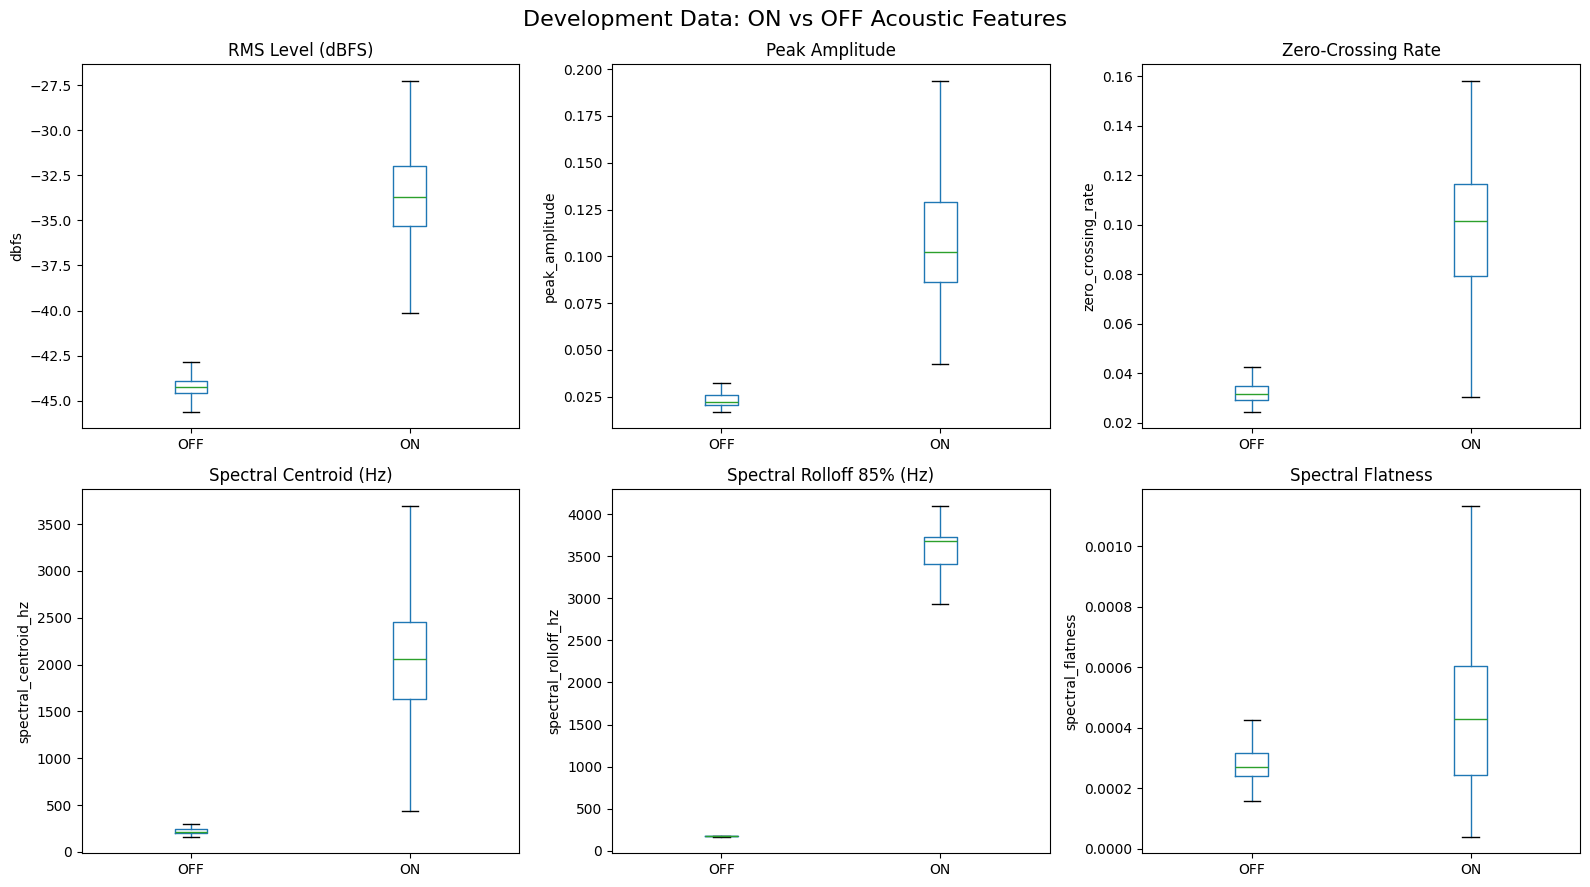

In [ ]:
fig, axes = plt.subplots(
    2,
    3,
    figsize=(16, 9),
)

axes = axes.flatten()

plot_titles = {
    "dbfs": "RMS Level (dBFS)",
    "peak_amplitude": "Peak Amplitude",
    "zero_crossing_rate": "Zero-Crossing Rate",
    "spectral_centroid_hz": "Spectral Centroid (Hz)",
    "spectral_rolloff_hz": "Spectral Rolloff 85% (Hz)",
    "spectral_flatness": "Spectral Flatness",
}

for axis, feature_name in zip(
    axes,
    feature_columns,
):
    development_features.boxplot(
        column=feature_name,
        by="label",
        ax=axis,
        showfliers=False,
        grid=False,
    )

    axis.set_title(
        plot_titles[feature_name]
    )
    axis.set_xlabel("")
    axis.set_ylabel(feature_name)

fig.suptitle(
    "Development Data: ON vs OFF Acoustic Features",
    fontsize=16,
)

plt.tight_layout()
plt.show()

## 선택된 OFF 구간을 WAV 파일로 저장

각 공정의 앞뒤에서 선택한 OFF 구간을 별도의 WAV 파일로 저장한다.

총 27개 실험에서 앞·뒤 구간을 하나씩 저장하므로 54개 파일이 생성된다. 데이터 분할별 하위 폴더를 사용해 개발 데이터와 최종 테스트 데이터가 섞이지 않도록 한다.

In [ ]:
OFF_DIR = PROCESSED_DIR / "[5] off"

OFF_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

saved_off_records = []

for _, off_row in selected_off_intervals.iterrows():
    raw_path = raw_path_map[
        off_row["raw_file"]
    ]

    role_directory = (
        OFF_DIR / off_row["dataset_role"]
    )

    role_directory.mkdir(
        parents=True,
        exist_ok=True,
    )

    output_name = (
        f"experiment_"
        f"{int(off_row['source_experiment_id']):02d}_"
        f"{off_row['side']}.wav"
    )

    output_path = (
        role_directory / output_name
    )

    with sf.SoundFile(
        str(raw_path),
        "r",
    ) as raw_audio:
        sample_rate = raw_audio.samplerate

        start_frame = int(
            round(
                off_row["start_sec"]
                * sample_rate
            )
        )

        frame_count = int(
            round(
                off_row["duration_sec"]
                * sample_rate
            )
        )

        raw_audio.seek(start_frame)

        off_signal = raw_audio.read(
            frame_count,
            dtype="int16",
            always_2d=False,
        )

    sf.write(
        str(output_path),
        off_signal,
        sample_rate,
        subtype="PCM_16",
    )

    saved_off_records.append({
        **off_row.to_dict(),
        "saved_file": output_name,
        "saved_path": str(output_path),
        "saved_duration_sec": (
            len(off_signal) / sample_rate
        ),
        "sample_rate": sample_rate,
    })

saved_off_intervals = pd.DataFrame(
    saved_off_records
)

display(
    saved_off_intervals[
        [
            "source_experiment_id",
            "side",
            "dataset_role",
            "saved_file",
            "saved_duration_sec",
            "sample_rate",
        ]
    ]
)

,source_experiment_id,side,dataset_role,saved_file,saved_duration_sec,sample_rate
0,1,after,development_A,experiment_01_after.wav,20.0,48000
1,1,before,development_A,experiment_01_before.wav,20.0,48000
2,2,after,development_A,experiment_02_after.wav,20.0,48000
3,2,before,development_A,experiment_02_before.wav,20.0,48000
4,3,after,development_A,experiment_03_after.wav,20.0,48000
5,3,before,development_A,experiment_03_before.wav,20.0,48000
6,4,after,development_A,experiment_04_after.wav,20.0,48000
7,4,before,development_A,experiment_04_before.wav,20.0,48000
8,5,after,development_A,experiment_05_after.wav,20.0,48000
9,5,before,development_A,experiment_05_before.wav,20.0,48000


## 저장된 OFF 파일 검증

분할별 OFF 파일 개수와 총 재생 시간을 확인한다.

각 분할에 18개 파일과 총 360초가 있으면 정상이다.

In [ ]:
saved_off_summary = (
    saved_off_intervals
    .groupby("dataset_role")
    .agg(
        file_count=("saved_file", "count"),
        total_duration_sec=(
            "saved_duration_sec",
            "sum",
        ),
        min_duration_sec=(
            "saved_duration_sec",
            "min",
        ),
        max_duration_sec=(
            "saved_duration_sec",
            "max",
        ),
        sample_rate_min=(
            "sample_rate",
            "min",
        ),
        sample_rate_max=(
            "sample_rate",
            "max",
        ),
    )
    .round(3)
)

display(saved_off_summary)

print(
    "저장된 OFF 파일 총개수:",
    len(
        list(
            OFF_DIR.rglob("*.wav")
        )
    ),
)

,file_count,total_duration_sec,min_duration_sec,max_duration_sec,sample_rate_min,sample_rate_max
dataset_role,,,,,,
development_A,18,360.0,20.0,20.0,48000,48000
development_B,18,360.0,20.0,20.0,48000,48000
test_holdout,18,360.0,20.0,20.0,48000,48000


저장된 OFF 파일 총개수: 54


## 최종 ON/OFF 학습 manifest 생성

ON은 실험별 segment 파일을 사용하고, OFF는 별도로 저장한 54개 WAV 파일을 사용한다.

각 음원을 1초 길이, 0.5초 이동 간격으로 나누어 다음 정보를 기록한다.

- ON/OFF 라벨
- 개발 또는 최종 테스트 분할
- 실험 번호
- 음원 파일의 상대경로
- 윈도우 시작·종료 시각

파일 경로는 프로젝트 폴더 기준 상대경로로 저장하므로 Google Drive 위치가 달라져도 `PROJECT_DIR`만 변경하면 사용할 수 있다.

In [ ]:
final_window_records = []


# ON 윈도우 생성
for experiment_id in range(1, 28):
    segment_path = (
        SEGMENT_DIR / f"{experiment_id}.wav"
    )

    segment_duration = sf.info(
        str(segment_path)
    ).duration

    dataset_role = role_map[
        experiment_id
    ]

    relative_path = str(
        segment_path.relative_to(
            PROJECT_DIR
        )
    )

    window_starts = np.arange(
        0.0,
        segment_duration - WINDOW_SECONDS + 1e-9,
        HOP_SECONDS,
    )

    for start_sec in window_starts:
        final_window_records.append({
            "label": "ON",
            "label_id": 1,
            "dataset_role": dataset_role,
            "experiment_id": experiment_id,
            "source_type": "segment",
            "source_file": segment_path.name,
            "relative_path": relative_path,
            "side": "",
            "start_sec": float(start_sec),
            "end_sec": float(
                start_sec + WINDOW_SECONDS
            ),
        })


# 저장된 OFF WAV에서 윈도우 생성
for _, off_row in saved_off_intervals.iterrows():
    saved_path = Path(
        off_row["saved_path"]
    )

    relative_path = str(
        saved_path.relative_to(
            PROJECT_DIR
        )
    )

    saved_duration = (
        off_row["saved_duration_sec"]
    )

    window_starts = np.arange(
        0.0,
        saved_duration - WINDOW_SECONDS + 1e-9,
        HOP_SECONDS,
    )

    for start_sec in window_starts:
        final_window_records.append({
            "label": "OFF",
            "label_id": 0,
            "dataset_role": off_row["dataset_role"],
            "experiment_id": int(
                off_row["source_experiment_id"]
            ),
            "source_type": "saved_off",
            "source_file": saved_path.name,
            "relative_path": relative_path,
            "side": off_row["side"],
            "start_sec": float(start_sec),
            "end_sec": float(
                start_sec + WINDOW_SECONDS
            ),
        })


final_window_manifest = (
    pd.DataFrame(final_window_records)
    .sort_values(
        [
            "dataset_role",
            "experiment_id",
            "label_id",
            "side",
            "start_sec",
        ]
    )
    .reset_index(drop=True)
)

final_window_manifest.insert(
    0,
    "window_id",
    [
        f"window_{index:05d}"
        for index in range(
            1,
            len(final_window_manifest) + 1,
        )
    ],
)

display(final_window_manifest.head(10))

,window_id,label,label_id,dataset_role,experiment_id,source_type,source_file,relative_path,side,start_sec,end_sec
0,window_00001,OFF,0,development_A,1,saved_off,experiment_01_after.wav,[2] processed sound data/[5] off/development_A...,after,0.0,1.0
1,window_00002,OFF,0,development_A,1,saved_off,experiment_01_after.wav,[2] processed sound data/[5] off/development_A...,after,0.5,1.5
2,window_00003,OFF,0,development_A,1,saved_off,experiment_01_after.wav,[2] processed sound data/[5] off/development_A...,after,1.0,2.0
3,window_00004,OFF,0,development_A,1,saved_off,experiment_01_after.wav,[2] processed sound data/[5] off/development_A...,after,1.5,2.5
4,window_00005,OFF,0,development_A,1,saved_off,experiment_01_after.wav,[2] processed sound data/[5] off/development_A...,after,2.0,3.0
5,window_00006,OFF,0,development_A,1,saved_off,experiment_01_after.wav,[2] processed sound data/[5] off/development_A...,after,2.5,3.5
6,window_00007,OFF,0,development_A,1,saved_off,experiment_01_after.wav,[2] processed sound data/[5] off/development_A...,after,3.0,4.0
7,window_00008,OFF,0,development_A,1,saved_off,experiment_01_after.wav,[2] processed sound data/[5] off/development_A...,after,3.5,4.5
8,window_00009,OFF,0,development_A,1,saved_off,experiment_01_after.wav,[2] processed sound data/[5] off/development_A...,after,4.0,5.0
9,window_00010,OFF,0,development_A,1,saved_off,experiment_01_after.wav,[2] processed sound data/[5] off/development_A...,after,4.5,5.5


## 최종 manifest 검증

최종 manifest의 클래스별 윈도우 개수, 경로 유효성 및 중복 여부를 검사한다.

기존 초기 manifest와 동일하게 총 4,531개의 윈도우가 생성돼야 한다.

In [ ]:
final_window_count_table = pd.crosstab(
    final_window_manifest["dataset_role"],
    final_window_manifest["label"],
)

final_window_count_table["total"] = (
    final_window_count_table.sum(axis=1)
)

display(final_window_count_table)


missing_path_count = sum(
    not (
        PROJECT_DIR / relative_path
    ).exists()
    for relative_path in (
        final_window_manifest["relative_path"]
        .unique()
    )
)

duplicate_count = (
    final_window_manifest[
        [
            "relative_path",
            "start_sec",
            "end_sec",
            "label",
            "dataset_role",
        ]
    ]
    .duplicated()
    .sum()
)

invalid_duration_count = (
    (
        final_window_manifest["end_sec"]
        - final_window_manifest["start_sec"]
    ).sub(WINDOW_SECONDS).abs()
    > 1e-9
).sum()


print(
    "최종 윈도우 수:",
    len(final_window_manifest),
)

print(
    "존재하지 않는 음원 경로 수:",
    missing_path_count,
)

print(
    "중복 윈도우 수:",
    duplicate_count,
)

print(
    "길이가 1초가 아닌 윈도우 수:",
    invalid_duration_count,
)

label,OFF,ON,total
dataset_role,,,
development_A,702,807,1509
development_B,702,809,1511
test_holdout,702,809,1511


최종 윈도우 수: 4531
존재하지 않는 음원 경로 수: 0
중복 윈도우 수: 0
길이가 1초가 아닌 윈도우 수: 0


## 최종 데이터 메타데이터 저장

모델 학습과 향후 공정 단계 분석에 필요한 최종 메타데이터만 Google Drive에 저장한다.

저장 대상:

- 실험조건과 데이터 분할
- Plunge/Dwell 위치
- 원본 내 ON 위치
- 최종 선택된 OFF 정보
- ON/OFF 학습 윈도우 manifest

중간 결과인 전체 OFF 후보, 초기 manifest와 탐색적 특징값은 저장하지 않는다.

In [ ]:
METADATA_DIR = (
    PROJECT_DIR / "[3] metadata"
)

METADATA_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# OFF 저장 경로를 프로젝트 기준 상대경로로 변환
selected_off_export = (
    saved_off_intervals.copy()
)

selected_off_export[
    "saved_relative_path"
] = selected_off_export[
    "saved_path"
].apply(
    lambda path: str(
        Path(path).relative_to(
            PROJECT_DIR
        )
    )
)

selected_off_export = (
    selected_off_export.drop(
        columns=["saved_path"]
    )
)


# 최종 메타데이터 저장
phase_duration_table.to_csv(
    METADATA_DIR / "phase_duration_table.csv",
    index=False,
)

phase_locations.to_csv(
    METADATA_DIR / "phase_locations.csv",
    index=False,
)

on_intervals.to_csv(
    METADATA_DIR / "on_intervals.csv",
    index=False,
)

selected_off_export.to_csv(
    METADATA_DIR / "selected_off_intervals.csv",
    index=False,
)

final_window_manifest.to_csv(
    METADATA_DIR / "window_manifest.csv",
    index=False,
)


print("저장 위치:")
print(METADATA_DIR)

print("\n저장된 최종 메타데이터:")

required_metadata_files = [
    "phase_duration_table.csv",
    "phase_locations.csv",
    "on_intervals.csv",
    "selected_off_intervals.csv",
    "window_manifest.csv",
]

for file_name in required_metadata_files:
    file_path = (
        METADATA_DIR / file_name
    )

    print(
        file_name,
        "| 존재:",
        file_path.exists(),
        "| 크기:",
        f"{file_path.stat().st_size / 1024:.1f} KB",
    )

저장 위치:
/content/drive/MyDrive/Friction Stir Spot Welding (FSSW)/[3] metadata

저장된 최종 메타데이터:
phase_duration_table.csv | 존재: True | 크기: 1.4 KB
phase_locations.csv | 존재: True | 크기: 2.7 KB
on_intervals.csv | 존재: True | 크기: 3.1 KB
selected_off_intervals.csv | 존재: True | 크기: 11.4 KB
window_manifest.csv | 존재: True | 크기: 599.7 KB


## 5-stage WAV 파일 기본 구성 확인

Approach, Plunge, Dwell, Retract 폴더에서 실험 1~27의 WAV 파일이 모두 존재하는지 검사한다.

각 stage별로 파일 개수, 샘플링레이트, 채널과 재생시간 범위를 확인한다.

In [9]:
APPROACH_DIR = (
    PROCESSED_DIR / "[1] approach"
)
RETRACT_DIR = (
    PROCESSED_DIR / "[4] retract"
)
OFF_DIR = (
    PROCESSED_DIR / "[5] off"
)

stage_directories = {
    "approach": APPROACH_DIR,
    "plunge": PLUNGE_DIR,
    "dwell": DWELL_DIR,
    "retract": RETRACT_DIR,
}


def make_numbered_file_map(folder):
    file_map = {}

    for path in folder.glob("*.wav"):
        if re.fullmatch(r"\d+", path.stem):
            file_map[int(path.stem)] = path

    return file_map


stage_file_maps = {
    stage_name: make_numbered_file_map(folder)
    for stage_name, folder
    in stage_directories.items()
}

stage_summary_records = []

for stage_name, file_map in stage_file_maps.items():
    expected_ids = set(range(1, 28))
    actual_ids = set(file_map)

    missing_ids = sorted(
        expected_ids - actual_ids
    )
    extra_ids = sorted(
        actual_ids - expected_ids
    )

    file_information = [
        sf.info(str(path))
        for path in file_map.values()
    ]

    durations = [
        information.frames
        / information.samplerate
        for information in file_information
    ]

    sample_rates = sorted({
        information.samplerate
        for information in file_information
    })

    channels = sorted({
        information.channels
        for information in file_information
    })

    stage_summary_records.append({
        "stage": stage_name,
        "file_count": len(file_map),
        "missing_ids": missing_ids,
        "extra_ids": extra_ids,
        "min_duration_sec": (
            min(durations) if durations else np.nan
        ),
        "mean_duration_sec": (
            np.mean(durations) if durations else np.nan
        ),
        "max_duration_sec": (
            max(durations) if durations else np.nan
        ),
        "sample_rates": sample_rates,
        "channels": channels,
    })

stage_file_summary = pd.DataFrame(
    stage_summary_records
)

display(stage_file_summary)

,stage,file_count,missing_ids,extra_ids,min_duration_sec,mean_duration_sec,max_duration_sec,sample_rates,channels
0,approach,27,[],[],12.51,12.510000,12.510,[48000],[1]
1,plunge,27,[],[],6.00,6.750000,7.500,[48000],[1]
2,dwell,27,[],[],4.00,7.000000,10.000,[48000],[1]
3,retract,27,[],[],18.53,19.299704,20.135,[48000],[1]


## 실험별 4개 stage와 전체 segment 길이 비교

각 실험의 Approach, Plunge, Dwell, Retract 길이를 합산하고 전체 segment 길이와 비교한다.

두 길이가 일치하면 네 stage가 전체 공정 구간을 빈틈없이 구성하는 것으로 볼 수 있다. 차이가 있다면 stage 사이의 누락 구간이나 추가 구간을 조사해야 한다.

In [10]:
stage_duration_records = []

for experiment_id in range(1, 28):
    segment_path = (
        SEGMENT_DIR / f"{experiment_id}.wav"
    )

    record = {
        "experiment_id": experiment_id,
    }

    stage_duration_sum = 0.0
    all_stage_files_exist = True

    for stage_name, file_map in stage_file_maps.items():
        stage_path = file_map.get(experiment_id)

        if stage_path is None:
            duration_sec = np.nan
            all_stage_files_exist = False
        else:
            information = sf.info(str(stage_path))
            duration_sec = (
                information.frames
                / information.samplerate
            )
            stage_duration_sum += duration_sec

        record[
            f"{stage_name}_duration_sec"
        ] = duration_sec

    if segment_path.exists():
        segment_information = sf.info(
            str(segment_path)
        )
        segment_duration_sec = (
            segment_information.frames
            / segment_information.samplerate
        )
    else:
        segment_duration_sec = np.nan

    record["stage_duration_sum_sec"] = (
        stage_duration_sum
        if all_stage_files_exist
        else np.nan
    )

    record["segment_duration_sec"] = (
        segment_duration_sec
    )

    record["duration_difference_sec"] = (
        stage_duration_sum
        - segment_duration_sec
        if (
            all_stage_files_exist
            and not np.isnan(segment_duration_sec)
        )
        else np.nan
    )

    stage_duration_records.append(record)

stage_duration_check = pd.DataFrame(
    stage_duration_records
)

display(
    stage_duration_check.round(6)
)

print(
    "최대 절대 길이 차이:",
    stage_duration_check[
        "duration_difference_sec"
    ].abs().max(),
    "초",
)

,experiment_id,approach_duration_sec,plunge_duration_sec,dwell_duration_sec,retract_duration_sec,stage_duration_sum_sec,segment_duration_sec,duration_difference_sec
0,1,12.51,6.00,4.0,18.590,41.100,41.100,-0.0
1,2,12.51,6.75,4.0,19.296,42.556,42.556,0.0
2,3,12.51,7.50,4.0,19.978,43.988,43.988,0.0
3,4,12.51,6.00,7.0,18.689,44.199,44.199,0.0
4,5,12.51,6.75,7.0,19.237,45.497,45.497,0.0
5,6,12.51,7.50,7.0,19.970,46.980,46.980,0.0
6,7,12.51,6.00,10.0,18.596,47.106,47.106,-0.0
7,8,12.51,6.75,10.0,19.279,48.539,48.539,0.0
8,9,12.51,7.50,10.0,20.087,50.097,50.097,-0.0
9,10,12.51,6.00,4.0,18.544,41.054,41.054,0.0


최대 절대 길이 차이: 7.105427357601002e-15 초


## Stage 파일과 전체 segment의 샘플 단위 일치 검증

각 실험의 Approach, Plunge, Dwell, Retract 파일을 순서대로 배치했을 때 전체 segment의 해당 위치와 음원 샘플이 정확히 같은지 검사한다.

이 검증이 통과하면 각 stage의 누적 길이를 신뢰할 수 있는 실제 경계 시각으로 사용할 수 있다.

In [11]:
stage_order = [
    "approach",
    "plunge",
    "dwell",
    "retract",
]

sample_match_records = []

for experiment_id in range(1, 28):
    segment_path = (
        SEGMENT_DIR / f"{experiment_id}.wav"
    )

    segment_audio, segment_sample_rate = sf.read(
        str(segment_path),
        dtype="int16",
        always_2d=False,
    )

    if segment_audio.ndim == 2:
        segment_audio = segment_audio[:, 0]

    cumulative_frame = 0

    for stage_name in stage_order:
        stage_path = stage_file_maps[
            stage_name
        ][experiment_id]

        stage_audio, stage_sample_rate = sf.read(
            str(stage_path),
            dtype="int16",
            always_2d=False,
        )

        if stage_audio.ndim == 2:
            stage_audio = stage_audio[:, 0]

        start_frame = cumulative_frame
        end_frame = (
            start_frame + len(stage_audio)
        )

        segment_slice = segment_audio[
            start_frame:end_frame
        ]

        sample_count_match = (
            len(segment_slice)
            == len(stage_audio)
        )

        if sample_count_match:
            sample_difference = (
                segment_slice.astype(np.int32)
                - stage_audio.astype(np.int32)
            )

            exact_sample_match = np.array_equal(
                segment_slice,
                stage_audio,
            )

            max_absolute_difference = (
                np.abs(sample_difference).max()
                if len(sample_difference) > 0
                else 0
            )

            rmse = float(
                np.sqrt(
                    np.mean(
                        sample_difference.astype(
                            np.float64
                        ) ** 2
                    )
                )
            )
        else:
            exact_sample_match = False
            max_absolute_difference = np.nan
            rmse = np.nan

        sample_match_records.append({
            "experiment_id": experiment_id,
            "stage": stage_name,
            "segment_start_frame": start_frame,
            "segment_end_frame": end_frame,
            "stage_frame_count": len(stage_audio),
            "sample_rate_match": (
                stage_sample_rate
                == segment_sample_rate
            ),
            "sample_count_match": (
                sample_count_match
            ),
            "exact_sample_match": (
                exact_sample_match
            ),
            "max_absolute_difference": (
                max_absolute_difference
            ),
            "rmse": rmse,
        })

        cumulative_frame = end_frame

    sample_match_records[-1][
        "full_segment_frame_count"
    ] = len(segment_audio)

    sample_match_records[-1][
        "final_cumulative_frame"
    ] = cumulative_frame

stage_sample_check = pd.DataFrame(
    sample_match_records
)

print(
    "전체 비교 개수:",
    len(stage_sample_check),
)

print(
    "샘플레이트 불일치:",
    (~stage_sample_check[
        "sample_rate_match"
    ]).sum(),
)

print(
    "샘플 개수 불일치:",
    (~stage_sample_check[
        "sample_count_match"
    ]).sum(),
)

print(
    "샘플값 불일치:",
    (~stage_sample_check[
        "exact_sample_match"
    ]).sum(),
)

print(
    "전체 최대 샘플 차이:",
    stage_sample_check[
        "max_absolute_difference"
    ].max(),
)

print(
    "전체 최대 RMSE:",
    stage_sample_check["rmse"].max(),
)

problematic_stage_matches = stage_sample_check[
    (
        ~stage_sample_check[
            "sample_rate_match"
        ]
    )
    | (
        ~stage_sample_check[
            "sample_count_match"
        ]
    )
    | (
        ~stage_sample_check[
            "exact_sample_match"
        ]
    )
]

if len(problematic_stage_matches) == 0:
    print(
        "모든 stage 파일이 segment의 해당 위치와 "
        "샘플 단위로 정확히 일치합니다."
    )
else:
    display(problematic_stage_matches)

전체 비교 개수: 108
샘플레이트 불일치: 0
샘플 개수 불일치: 0
샘플값 불일치: 0
전체 최대 샘플 차이: 0
전체 최대 RMSE: 0.0
모든 stage 파일이 segment의 해당 위치와 샘플 단위로 정확히 일치합니다.


## 5-stage 구간 및 경계 metadata 생성

샘플 단위 검증을 통과한 Approach, Plunge, Dwell, Retract 파일의 프레임 수를 이용해 각 실험의 정확한 stage 시작·종료 시각을 계산한다.

두 가지 metadata를 생성한다.

- `stage_intervals`: 각 stage의 시작·종료 위치
- `stage_boundaries`: stage가 전환되는 정확한 위치

segment 시작과 종료 경계는 OFF 음향이 segment 외부에 있으므로 추후 원본 연속 음향과 연결해서 사용한다.

In [13]:
role_map = {}

for experiment_id in range(1, 28):
    if 1 <= experiment_id <= 9:
        role_map[experiment_id] = (
            "development_A"
        )
    elif 10 <= experiment_id <= 18:
        role_map[experiment_id] = (
            "development_B"
        )
    else:
        role_map[experiment_id] = (
            "test_holdout"
        )

print(
    pd.Series(role_map)
    .value_counts()
    .sort_index()
)
STAGE_TO_ID = {
    "off": 0,
    "approach": 1,
    "plunge": 2,
    "dwell": 3,
    "retract": 4,
}

stage_interval_records = []
stage_boundary_records = []

for experiment_id in range(1, 28):
    segment_path = (
        SEGMENT_DIR / f"{experiment_id}.wav"
    )

    segment_info = sf.info(str(segment_path))
    sample_rate = segment_info.samplerate
    cumulative_frame = 0

    experiment_stage_intervals = []

    for stage_name in stage_order:
        stage_path = stage_file_maps[
            stage_name
        ][experiment_id]

        stage_info = sf.info(str(stage_path))
        stage_frame_count = stage_info.frames

        start_frame = cumulative_frame
        end_frame = (
            start_frame + stage_frame_count
        )

        stage_interval_records.append({
            "experiment_id": experiment_id,
            "dataset_role": role_map[
                experiment_id
            ],
            "stage": stage_name,
            "stage_id": STAGE_TO_ID[
                stage_name
            ],
            "segment_file": segment_path.name,
            "stage_file": stage_path.name,
            "sample_rate": sample_rate,
            "start_frame": start_frame,
            "end_frame": end_frame,
            "start_sec": (
                start_frame / sample_rate
            ),
            "end_sec": (
                end_frame / sample_rate
            ),
            "duration_sec": (
                stage_frame_count / sample_rate
            ),
        })

        experiment_stage_intervals.append({
            "stage": stage_name,
            "start_frame": start_frame,
            "end_frame": end_frame,
        })

        cumulative_frame = end_frame

    # OFF → Approach
    stage_boundary_records.append({
        "experiment_id": experiment_id,
        "dataset_role": role_map[
            experiment_id
        ],
        "boundary_index": 0,
        "from_stage": "off",
        "to_stage": "approach",
        "segment_frame": 0,
        "segment_sec": 0.0,
        "requires_external_audio": True,
    })

    # Approach → Plunge,
    # Plunge → Dwell,
    # Dwell → Retract
    for boundary_index in range(1, 4):
        previous_stage = (
            experiment_stage_intervals[
                boundary_index - 1
            ]
        )
        next_stage = (
            experiment_stage_intervals[
                boundary_index
            ]
        )

        boundary_frame = previous_stage[
            "end_frame"
        ]

        stage_boundary_records.append({
            "experiment_id": experiment_id,
            "dataset_role": role_map[
                experiment_id
            ],
            "boundary_index": boundary_index,
            "from_stage": previous_stage[
                "stage"
            ],
            "to_stage": next_stage[
                "stage"
            ],
            "segment_frame": boundary_frame,
            "segment_sec": (
                boundary_frame / sample_rate
            ),
            "requires_external_audio": False,
        })

    # Retract → OFF
    stage_boundary_records.append({
        "experiment_id": experiment_id,
        "dataset_role": role_map[
            experiment_id
        ],
        "boundary_index": 4,
        "from_stage": "retract",
        "to_stage": "off",
        "segment_frame": cumulative_frame,
        "segment_sec": (
            cumulative_frame / sample_rate
        ),
        "requires_external_audio": True,
    })


stage_intervals = pd.DataFrame(
    stage_interval_records
)

stage_boundaries = pd.DataFrame(
    stage_boundary_records
)

display(stage_intervals.head(12))
display(stage_boundaries.head(15))

print(
    "Stage 구간 수:",
    len(stage_intervals),
)

print(
    "전체 경계 수:",
    len(stage_boundaries),
)

print(
    "\n경계 종류별 개수:"
)

display(
    stage_boundaries.groupby(
        [
            "from_stage",
            "to_stage",
            "requires_external_audio",
        ]
    )
    .size()
    .rename("count")
    .reset_index()
)

development_A    9
development_B    9
test_holdout     9
Name: count, dtype: int64


,experiment_id,dataset_role,stage,stage_id,segment_file,stage_file,sample_rate,start_frame,end_frame,start_sec,end_sec,duration_sec
0,1,development_A,approach,1,1.wav,1.wav,48000,0,600480,0.00,12.510,12.510
1,1,development_A,plunge,2,1.wav,1.wav,48000,600480,888480,12.51,18.510,6.000
2,1,development_A,dwell,3,1.wav,1.wav,48000,888480,1080480,18.51,22.510,4.000
3,1,development_A,retract,4,1.wav,1.wav,48000,1080480,1972800,22.51,41.100,18.590
4,2,development_A,approach,1,2.wav,2.wav,48000,0,600480,0.00,12.510,12.510
5,2,development_A,plunge,2,2.wav,2.wav,48000,600480,924480,12.51,19.260,6.750
6,2,development_A,dwell,3,2.wav,2.wav,48000,924480,1116480,19.26,23.260,4.000
7,2,development_A,retract,4,2.wav,2.wav,48000,1116480,2042688,23.26,42.556,19.296
8,3,development_A,approach,1,3.wav,3.wav,48000,0,600480,0.00,12.510,12.510
9,3,development_A,plunge,2,3.wav,3.wav,48000,600480,960480,12.51,20.010,7.500


,experiment_id,dataset_role,boundary_index,from_stage,to_stage,segment_frame,segment_sec,requires_external_audio
0,1,development_A,0,off,approach,0,0.000,True
1,1,development_A,1,approach,plunge,600480,12.510,False
2,1,development_A,2,plunge,dwell,888480,18.510,False
3,1,development_A,3,dwell,retract,1080480,22.510,False
4,1,development_A,4,retract,off,1972800,41.100,True
5,2,development_A,0,off,approach,0,0.000,True
6,2,development_A,1,approach,plunge,600480,12.510,False
7,2,development_A,2,plunge,dwell,924480,19.260,False
8,2,development_A,3,dwell,retract,1116480,23.260,False
9,2,development_A,4,retract,off,2042688,42.556,True


Stage 구간 수: 108
전체 경계 수: 135

경계 종류별 개수:


,from_stage,to_stage,requires_external_audio,count
0,approach,plunge,False,27
1,dwell,retract,False,27
2,off,approach,True,27
3,plunge,dwell,False,27
4,retract,off,True,27


## 5-stage 구간 및 경계 metadata 저장

검증된 108개 stage 구간과 135개 경계를 모델 학습에서 사용할 수 있도록 metadata 폴더에 저장한다.

In [14]:
METADATA_DIR = (
    PROJECT_DIR / "[3] metadata"
)

METADATA_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

stage_intervals_path = (
    METADATA_DIR / "stage_intervals.csv"
)

stage_boundaries_path = (
    METADATA_DIR / "stage_boundaries.csv"
)

stage_intervals.to_csv(
    stage_intervals_path,
    index=False,
)

stage_boundaries.to_csv(
    stage_boundaries_path,
    index=False,
)

print(
    "stage_intervals.csv:",
    stage_intervals_path.exists(),
    len(stage_intervals),
    "행",
)

print(
    "stage_boundaries.csv:",
    stage_boundaries_path.exists(),
    len(stage_boundaries),
    "행",
)

stage_intervals.csv: True 108 행
stage_boundaries.csv: True 135 행
